# ex001_PHT3D_01

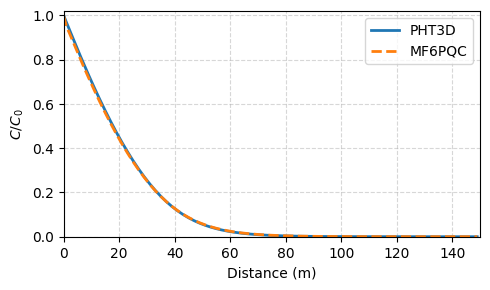

,RMSE
Variable,
Spe,0.0047792


In [5]:
import pandas as pd
from IPython.display import display

comparison_rows = []
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CASE_DIR = Path.cwd()
output = CASE_DIR / "output"
results = np.load(output / "results.npy")
headings = (output / "results_headings.txt").read_text(encoding="utf-8-sig").splitlines()
mf6pqc = results[-1, headings.index("Spe")]
pht3d = np.load(CASE_DIR / "input_data/PHT3D_01_results.npy")["Spe"]
comparison_rows.append({"Variable": "Spe", "RMSE": np.sqrt(np.mean((mf6pqc - pht3d) ** 2))})
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(np.arange(pht3d.size), pht3d, label="PHT3D", linewidth=2)
ax.plot(np.arange(mf6pqc.size), mf6pqc, "--", label="MF6PQC", linewidth=2)
ax.set(xlabel="Distance (m)", ylabel="$C/C_0$", xlim=(0, 150), ylim=(0, 1.02))
ax.legend()
ax.grid(visible=True, which="major", axis="both", alpha=0.5, linestyle="--")
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()
comparison = pd.DataFrame(comparison_rows)
comparison = comparison.set_index("Variable")
display(comparison.style.format({"RMSE": "{:.6g}"}).set_uuid("ex001_1"))